In [1]:
import os
import sys
import time
from typing import Optional, Sequence, Tuple, List

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import json

from openai import OpenAI

# Load environment variables from current directory .env and override existing ones
load_dotenv(".env", override=True)

# load api key from environment
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in .env file")
    
client = OpenAI(api_key=api_key)

In [2]:
#df = pd.read_json("hf://datasets/HannahRoseKirk/prism-alignment/survey.jsonl", lines=True)

# Use the self-written constitution with respect to how participants want AI Language models to behave
#mask_principles = df["system_string"].notna()
#self_written_ai_principles = df.loc[mask_principles, "system_string"].tolist()
#principle_df_indices = df.index[mask_principles].to_numpy()

In [3]:
decomposed_path = r"C:\Users\laras\OneDrive\Dokumente\duke_classes\icai_project\Principle-Elicitation\DecontextualPrinciples\self_written_ai_principles_decomposed.json"
with open(decomposed_path, "r", encoding="utf-8") as f:
    decomposed = json.load(f)

df = pd.DataFrame(decomposed) 

# Mask at the constitution-row level (rows that have at least 1 extracted principle)
mask_principles = df["principles"].apply(lambda x: isinstance(x, list) and len(x) > 0)

# Flatten principles AND create matching indices (one index per flattened principle)
self_written_ai_principles = []
principle_df_indices = []

for idx, plist in df.loc[mask_principles, "principles"].items():
    for p in plist:
        if isinstance(p, str) and p.strip():
            self_written_ai_principles.append(p.strip())
            principle_df_indices.append(idx)

principle_df_indices = np.array(principle_df_indices)

print("Num constitutions in saved file:", len(df))
print("Num constitutions with principles:", int(mask_principles.sum()))
print("Num generated principles:", len(self_written_ai_principles))
print("Indices length matches principles:", len(principle_df_indices) == len(self_written_ai_principles))
print("Example principle:", self_written_ai_principles[0] if self_written_ai_principles else "N/A")

Num constitutions in saved file: 1500
Num constitutions with principles: 1500
Num generated principles: 4115
Indices length matches principles: True
Example principle: AI should provide accurate information.


In [4]:
def get_embedding(principle):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.embeddings.create(
                input=principle,
                model="text-embedding-3-small",
            )
            return response.data[0].embedding
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [5]:
def summarize_cluster(cluster, prompt, summary_prompt):
    num_retries = 0
    max_retries = 5
    while True:
        try:
            response = client.chat.completions.create(
                model="gpt-4.1-2025-04-14",
                messages=[
                    {"role": "system", "content": summary_prompt},
                    {"role": "user", "content": prompt}
                ],
            )
            summary = response.choices[0].message.content.strip()
            return({
                "cluster_id": cluster["cluster_id"],
                "summarized_principle": summary,
                "original_principles": cluster["principles"]
            })
            break
        except Exception as e:
            print(f"Error: {e}. Retrying in 5 seconds...")
            num_retries += 1
            if num_retries >= max_retries:
                print("Max retries reached. Exiting.")
                sys.exit(1)
            time.sleep(5)

In [6]:
emb_path = "self_written_ai_principles_split_embeddings.npy"

if os.path.exists(emb_path):
    print(f"Loading embeddings from {emb_path}")
    X = np.load(emb_path)
    X = np.asarray(X, dtype=np.float32)
else:
    print("No saved embeddings found. Computing embeddings now...")
    embeddings = []
    for p in tqdm(self_written_ai_principles, desc="Computing embeddings"):
        embeddings.append(get_embedding(p))

    X = np.vstack(embeddings)
    np.save(emb_path, X)
    print(f"Saved embeddings to {emb_path}")

print("Embeddings shape:", X.shape)

Loading embeddings from self_written_ai_principles_split_embeddings.npy
Embeddings shape: (4115, 1536)


In [7]:
def pairwise_distances(points):
    points = np.asarray(points, dtype=np.float32)
    sq_norms = np.sum(points ** 2, axis=1)
    D2 = sq_norms[:, None] + sq_norms[None, :] - 2.0 * (points @ points.T)
    D2 = np.maximum(D2, 0.0)
    return np.sqrt(D2)


def greedy_capture_fair_clustering(points, k):
    """Greedy Capture Algorithhm"""
    points = np.asarray(points, dtype=np.float32)
    n = points.shape[0]
    
    dist = pairwise_distances(points)  

    events = []
    for i in range(n):
        for j in range(n):
            events.append((dist[i, j], i, j))
    events.sort(key=lambda t: t[0])

    quota = int(np.ceil(n / k))
    remaining = set(range(n))
    open_centers = []
    ball_points = [set() for _ in range(n)]

    for d_ij, i, j in events:
        if not remaining:
            break
        if len(open_centers) >= k:
            break
        if i not in remaining:
            continue

        if j in open_centers:
            remaining.remove(i)
        else:
            ball_points[j].add(i)
            if len(ball_points[j]) >= quota:
                open_centers.append(j)
                for p in ball_points[j]:
                    if p in remaining:
                        remaining.remove(p)
                ball_points[j].clear()

    open_centers = np.array(open_centers, dtype=int)

    dist_to_open = dist[:, open_centers]
    labels = np.argmin(dist_to_open, axis=1)

    return open_centers, labels, dist

In [8]:
clusters = 50

center_idx_gc, labels_gc, dist_gc = greedy_capture_fair_clustering(X, clusters)

print("Greedy Capture")
print("  num_centers:", len(center_idx_gc))

Greedy Capture
  num_centers: 50


In [9]:
center_embed_indices_gc = center_idx_gc  

center_df_indices_gc = principle_df_indices[center_embed_indices_gc]

clusters_output = []

for cluster_id, center_embed_idx in enumerate(center_embed_indices_gc):
    cluster_embed_indices = np.where(labels_gc == cluster_id)[0]

    # map to constitution-row indices (still useful metadata)
    cluster_df_indices = principle_df_indices[cluster_embed_indices]
    center_df_idx = center_df_indices_gc[cluster_id]

    # cluster member principles (the actual items that were embedded/clustered)
    principles = [self_written_ai_principles[i] for i in cluster_embed_indices]

    # representative principle (center) text
    representative_principle = self_written_ai_principles[center_embed_idx]

    clusters_output.append(
        {
            "cluster_id": int(cluster_id),
            "center_embed_index": int(center_embed_idx),
            "center_df_index": int(center_df_idx),
            "representative_principle": representative_principle,
            "principles": principles,
        }
    )
rep_principles_gc = [self_written_ai_principles[i] for i in center_embed_indices_gc]

cluster_reps_gc = pd.DataFrame({
    "cluster_id": np.arange(len(center_embed_indices_gc)),
    "df_index": center_df_indices_gc,
    "representative_principle": rep_principles_gc,
})

cluster_reps_gc.to_json(
    f"cluster_representatives_greedy_capture_k={clusters}.json",
    orient="records",
    force_ascii=False
)

cluster_reps_gc



,cluster_id,df_index,representative_principle
0,0,834,AI should provide accurate and factual informa...
1,1,209,AI should provide factual and truthful informa...
2,2,777,AI should provide factual and accurate informa...
3,3,571,AI should provide factual and accurate informa...
4,4,505,AI should provide factual and truthful informa...
5,5,609,AI should provide accurate and factual informa...
6,6,969,AI should be honest and truthful.
7,7,98,AI should communicate in a friendly and kind m...
8,8,1217,AI should be honest and truthful.
9,9,2,AI should be kind and respectful.


In [10]:
clusters_output = []

for cluster_id, center_embed_idx in enumerate(center_embed_indices_gc):
    cluster_embed_indices = np.where(labels_gc == cluster_id)[0]

    # map to constitution-row indices (still useful metadata)
    cluster_df_indices = principle_df_indices[cluster_embed_indices]
    center_df_idx = center_df_indices_gc[cluster_id]

    # cluster member principles (the actual items that were embedded/clustered)
    principles = [self_written_ai_principles[i] for i in cluster_embed_indices]

    # representative principle (center) text
    representative_principle = self_written_ai_principles[center_embed_idx]

    clusters_output.append(
        {
            "cluster_id": int(cluster_id),
            "center_embed_index": int(center_embed_idx),
            "center_df_index": int(center_df_idx),
            "representative_principle": representative_principle,
            "principles": principles,
        }
    )


(array([8., 4., 5., 4., 3., 1., 0., 6., 3., 3., 0., 3., 1., 2., 2., 1., 0.,
        1., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([  2.        ,  13.36666667,  24.73333333,  36.1       ,
         47.46666667,  58.83333333,  70.2       ,  81.56666667,
         92.93333333, 104.3       , 115.66666667, 127.03333333,
        138.4       , 149.76666667, 161.13333333, 172.5       ,
        183.86666667, 195.23333333, 206.6       , 217.96666667,
        229.33333333, 240.7       , 252.06666667, 263.43333333,
        274.8       , 286.16666667, 297.53333333, 308.9       ,
        320.26666667, 331.63333333, 343.        ]),
 <BarContainer object of 30 artists>)

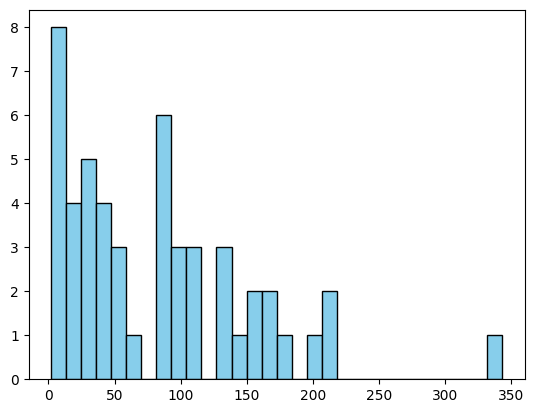

In [11]:
cluster_sizes = []
for cluster in clusters_output:
    cluster_sizes.append(len(cluster['principles']))


plt.hist(cluster_sizes, bins=30, color='skyblue', edgecolor='black')


In [12]:
with open('principle_summary_prompt.txt', 'r', encoding="utf-8") as f:
    summary_prompt = f.read()

k = 5
summarized_principles = []

for cluster in tqdm(clusters_output):
    cluster_id = cluster["cluster_id"]
    center_embed_idx = cluster["center_embed_index"]

    cluster_embed_indices = np.where(labels_gc == cluster_id)[0]

    d_to_center = dist_gc[center_embed_idx, cluster_embed_indices]

    local_order = np.argsort(d_to_center)[:k]
    chosen_embed_indices = cluster_embed_indices[local_order]

    # These are the actual principle strings that were embedded/clustered
    closest_principles = [self_written_ai_principles[i] for i in chosen_embed_indices]

    principles_text = "\n".join(
        f"{i+1}. {p}" for i, p in enumerate(closest_principles)
    )
    prompt = f"\n\nPrinciples:\n{principles_text}\n\nSummarized Principle:"

    entry = summarize_cluster(cluster, prompt, summary_prompt)

    entry["representative_principle"] = cluster["representative_principle"]
    entry["center_df_index"] = cluster["center_df_index"]

    summarized_principles.append(entry)

with open(f"cluster_summarized_greedy_capture_k={clusters}.json", "w", encoding="utf-8") as f:
    json.dump(summarized_principles, f, indent=4, ensure_ascii=False)



  0%|          | 0/50 [00:00<?, ?it/s]

In [13]:
print(f"{k} summarized clusters using Greedy Capture")
for princ in summarized_principles:
    print("Summarized Principle: " + princ["summarized_principle"] + "\n")

5 summarized clusters using Greedy Capture
Summarized Principle: AI should provide accurate, reliable, and unbiased information based on verifiable facts.

Summarized Principle: AI should consistently provide honest, factual, and truthful information.

Summarized Principle: AI should consistently provide information that is factual and accurate.

Summarized Principle: AI should provide consistently factual and accurate information.

Summarized Principle: AI should provide information that is accurate and truthful.

Summarized Principle: AI should consistently provide accurate, truthful, and relevant information to ensure users are well informed.

Summarized Principle: AI should consistently provide accurate and truthful information.

Summarized Principle: AI should communicate in a consistently kind and friendly manner.

Summarized Principle: AI should consistently uphold honesty and truthfulness in its interactions.

Summarized Principle: AI should consistently demonstrate kindness an